Elisabeth GIL - **EDA** - 2024

## Description of the spotify 2023 dataset

This dataset contains a comprehensive list of the most famous songs of 2023 as listed on Spotify. The dataset offers a wealth of features beyond what is typically available in similar datasets. It provides insights into each song's attributes, popularity, and presence on various music platforms. The dataset includes information such as track name, artist(s) name, release date, Spotify playlists and charts, streaming statistics, Apple Music presence, Deezer presence, Shazam charts, and various audio features.

In [ ]:
#necessary importations
import pandas as pd
import numpy as np
import calendar
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Attempting to read the CSV file using the default UTF-8 encoding caused a UnicodeDecodeError.
# To resolve this, we can specify a different encoding such as 'latin1', 'iso-8859-1', or 'cp1252'.
df=pd.read_csv("/kaggle/input/top-spotify-songs-2023/spotify-2023.csv", encoding='latin-1')

### EDA

### Initial Data Inspection

In [ ]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


The `df.head()` output above shows the first 5 rows of the dataset, giving us a quick overview of the columns and the type of data they contain.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

The `df.info()` output above provides a summary of the DataFrame, including the number of non-null entries for each column and their data types. This helps identify columns with missing values and incorrect data types.

In [ ]:
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,67.812172,51.908709,2.666317,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,86.441493,50.630241,6.035599,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,13.000000,7.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,34.000000,38.000000,0.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,88.000000,87.000000,2.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,672.000000,275.000000,58.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


The `df.describe()` output above gives statistical summaries of numerical columns, including count, mean, standard deviation, min, max, and quartile values. This helps us understand the distribution and spread of numerical features.

In [ ]:
df['release_date'] = pd.to_datetime(
    df[['released_year', 'released_month', 'released_day']].rename(
        columns={'released_year': 'year', 'released_month': 'month', 'released_day': 'day'}
    )
)


Here, a new `release_date` column was created by combining the `released_year`, `released_month`, and `released_day` columns into a single datetime object. This ensures that the release date is in a proper format for time-based analysis.

In [ ]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,release_date
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,B,Major,80,89,83,31,0,8,4,2023-07-14
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,C#,Major,71,61,74,7,0,10,4,2023-03-23
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,F,Major,51,32,53,17,0,31,6,2023-06-30
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,A,Major,55,58,72,11,0,11,15,2019-08-23
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,A,Minor,65,23,80,14,63,11,6,2023-05-18


In [ ]:
df.dtypes

track_name                      object
artist(s)_name                  object
artist_count                     int64
released_year                    int64
released_month                   int64
released_day                     int64
in_spotify_playlists             int64
in_spotify_charts                int64
streams                         object
in_apple_playlists               int64
in_apple_charts                  int64
in_deezer_playlists             object
in_deezer_charts                 int64
in_shazam_charts                object
bpm                              int64
key                             object
mode                            object
danceability_%                   int64
valence_%                        int64
energy_%                         int64
acousticness_%                   int64
instrumentalness_%               int64
liveness_%                       int64
speechiness_%                    int64
release_date            datetime64[ns]
dtype: object

The `df.dtypes` output above confirms that the `release_date` column has been successfully converted to a `datetime64[ns]` type. This is crucial for any time-series analysis.

In [ ]:
df['key'] = df['key'].fillna('Undefined')
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)

Missing values in 'key' were filled with 'Undefined', and 'in_shazam_charts' were filled with 0. This handles some initial missing data.

In [ ]:
non_numeric_indices = df[~df['streams'].str.isnumeric()].index
print("Indices of non-numeric rows:")
print(non_numeric_indices)

Indices of non-numeric rows:
Index([574], dtype='int64')


In [ ]:
for idx in non_numeric_indices:
    df.loc[idx, 'streams'] = '0'

The `streams` column was identified to have non-numeric values, specifically at index 574. The code above replaces the non-numeric value with '0' to enable conversion to a numeric type. Then the column is converted to numeric type and a scaled version is created.

In [ ]:
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

In [ ]:
streams_mean=np.round(df['streams'].mean())

In [ ]:
df.loc[574, 'streams'] = streams_mean

In [ ]:
df['streams'][574]

513597931

In [ ]:
df['streams_scaled'] = df['streams'] / 10000000

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   track_name            953 non-null    object        
 1   artist(s)_name        953 non-null    object        
 2   artist_count          953 non-null    int64         
 3   released_year         953 non-null    int64         
 4   released_month        953 non-null    int64         
 5   released_day          953 non-null    int64         
 6   in_spotify_playlists  953 non-null    int64         
 7   in_spotify_charts     953 non-null    int64         
 8   streams               953 non-null    int64         
 9   in_apple_playlists    953 non-null    int64         
 10  in_apple_charts       953 non-null    int64         
 11  in_deezer_playlists   953 non-null    object        
 12  in_deezer_charts      953 non-null    int64         
 13  in_shazam_charts    

The `df.info()` output after data cleaning confirms that the 'streams' column is now of type `int64` and 'streams_scaled' is `float64`, as intended. All non-null counts match the total entries, indicating no missing values in these critical columns.

In [ ]:
df.isnull().sum()

track_name              0
artist(s)_name          0
artist_count            0
released_year           0
released_month          0
released_day            0
in_spotify_playlists    0
in_spotify_charts       0
streams                 0
in_apple_playlists      0
in_apple_charts         0
in_deezer_playlists     0
in_deezer_charts        0
in_shazam_charts        0
bpm                     0
key                     0
mode                    0
danceability_%          0
valence_%               0
energy_%                0
acousticness_%          0
instrumentalness_%      0
liveness_%              0
speechiness_%           0
release_date            0
streams_scaled          0
dtype: int64

The `df.isnull().sum()` output above confirms that there are no remaining missing values across any columns in the dataset after the cleaning steps.

In [ ]:
df.duplicated().sum()

0

The `df.duplicated().sum()` output shows that there are no duplicate rows in the dataset, which is good for data integrity.

In [ ]:
df.sample(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,release_date,streams_scaled
340,Heaven,Niall Horan,1,2023,2,17,1553,2,144584800,61,...,Major,57,68,76,7,0,33,3,2023-02-17,14.458480
172,Do I Wanna Know?,Arctic Monkeys,1,2013,1,1,33783,26,1788326445,133,...,Major,55,42,53,17,0,22,3,2013-01-01,178.832644
311,Something in the Orange,Zach Bryan,1,2022,4,22,3282,12,449701773,67,...,Major,59,22,38,42,0,12,3,2022-04-22,44.970177
720,Wake Me Up - Radio Edit,Avicii,1,2013,1,1,50887,34,1970673297,315,...,Major,53,66,78,0,0,16,5,2013-01-01,197.067330
219,Superhero (Heroes & Villains) [with Future & C...,"Future, Chris Brown, Metro Boomin",3,2022,12,2,2959,16,401036314,41,...,Minor,72,45,59,14,0,20,21,2022-12-02,40.103631
617,Way 2 Sexy (with Future & Young Thug),"Drake, Future, Young Thug",3,2021,9,3,5481,0,489945871,144,...,Minor,80,33,60,0,0,32,14,2021-09-03,48.994587
124,Por las Noches,Peso Pluma,1,2021,6,11,457,24,330346424,8,...,Major,81,39,60,31,0,7,3,2021-06-11,33.034642
492,Desesperados,"Chencho Corleone, Rauw Alejandro",2,2021,6,25,6821,34,809306935,83,...,Minor,87,51,69,36,0,9,8,2021-06-25,80.930694
38,Style,Taylor Swift,1,2014,1,1,7830,42,786181836,94,...,Major,60,48,79,0,0,12,4,2014-01-01,78.618184
941,"Would've, Could've, Should've",Taylor Swift,1,2022,10,21,1715,0,177503916,4,...,Major,48,55,84,43,0,15,12,2022-10-21,17.750392


The `df.sample(10)` output displays 10 random rows from the DataFrame, providing a quick sanity check of the data after cleaning and processing.

### Data Visualization

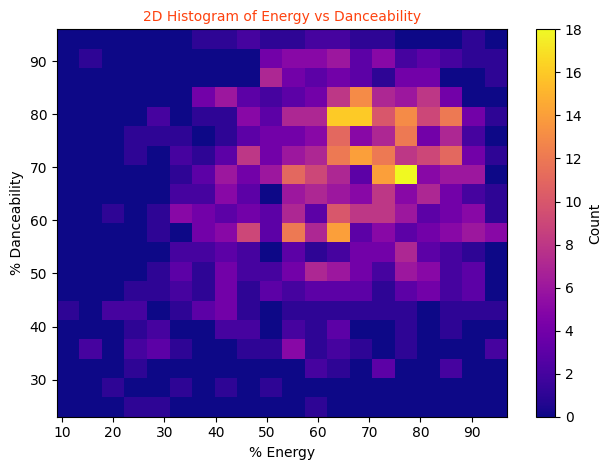

In [ ]:
fig, ax = plt.subplots(tight_layout=True)
hist = ax.hist2d(df['energy_%'],df['danceability_%'], bins=20, cmap='plasma')
cbar=plt.colorbar(hist[3],ax=ax)
cbar.set_label('Count', font='Times New Roman')
ax.set_xlabel('% Energy', font='Times New Roman')
ax.set_ylabel('% Danceability', font='Times New Roman')
ax.set_title('2D Histogram of Energy vs Danceability', color='#FE420F', font='Times New Roman')
plt.show()

The 2D histogram above visualizes the relationship between energy and danceability. It shows a concentration of songs with medium to high energy and danceability, indicating a trend in popular songs being both energetic and danceable.

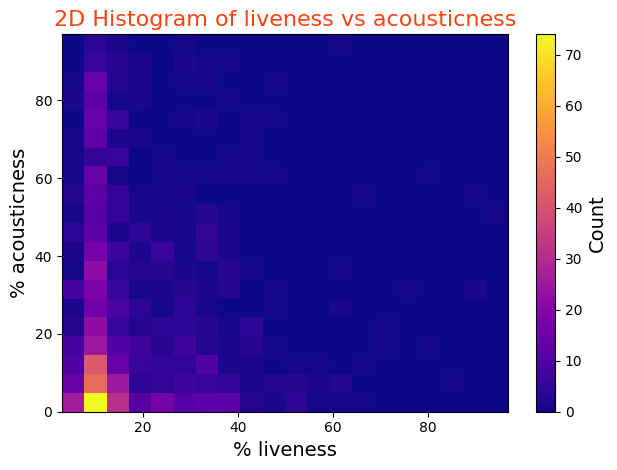

In [ ]:
fig, ax = plt.subplots(tight_layout=True)
hist = ax.hist2d(df['liveness_%'],df['acousticness_%'], bins=20, cmap='plasma')
cbar=plt.colorbar(hist[3],ax=ax)
cbar.set_label('Count', font='Times New Roman', fontsize='14')
ax.set_xlabel('% liveness', font='Times New Roman', fontsize='14')
ax.set_ylabel('% acousticness', font='Times New Roman', fontsize='14')
ax.set_title('2D Histogram of liveness vs acousticness', color='#FE420F', font='Times New Roman', fontsize='16')
plt.show()

The 2D histogram above illustrates the relationship between liveness and acousticness. Most songs tend to have low liveness and acousticness, suggesting that highly produced studio tracks are more common among the top songs.

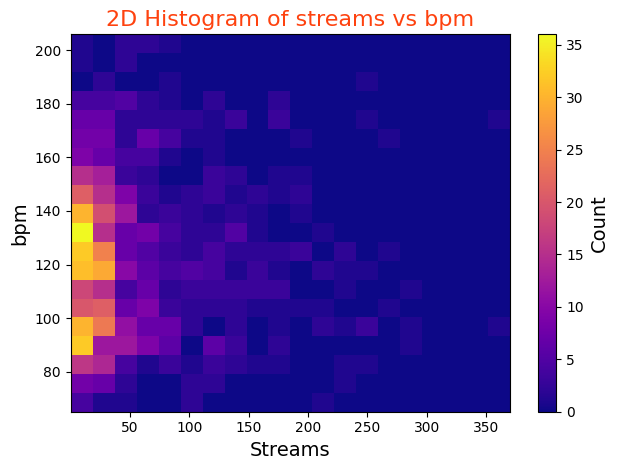

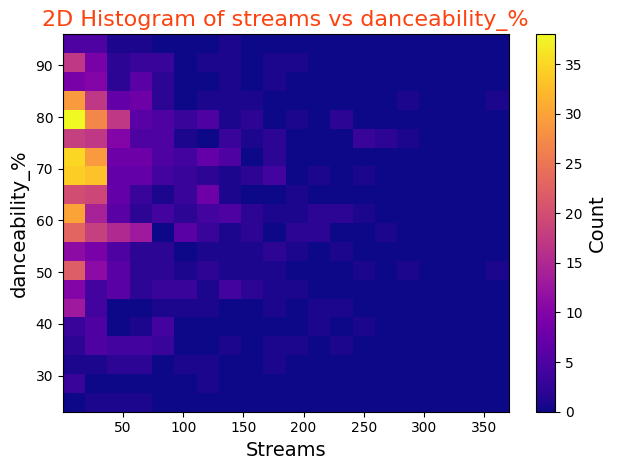

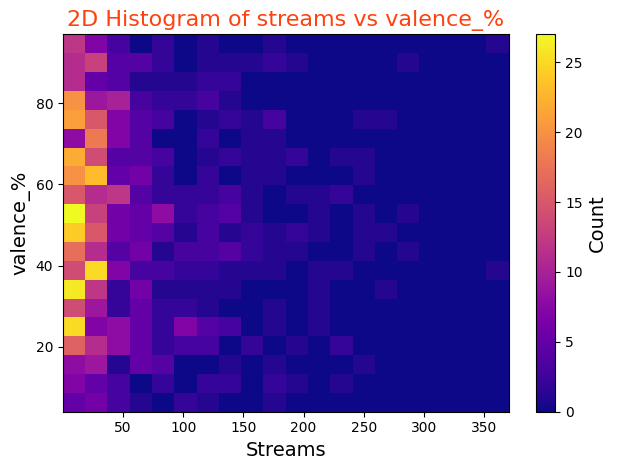

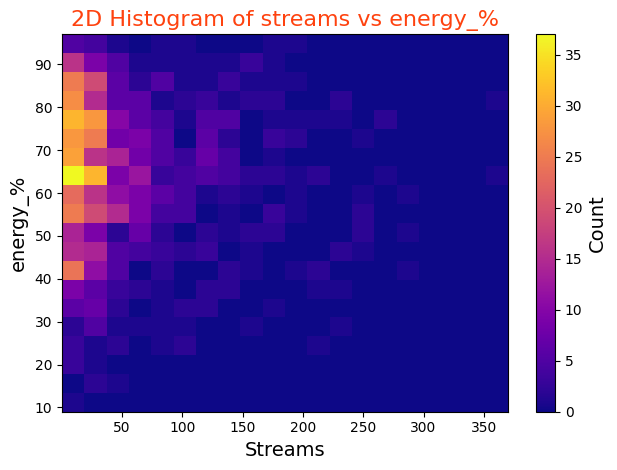

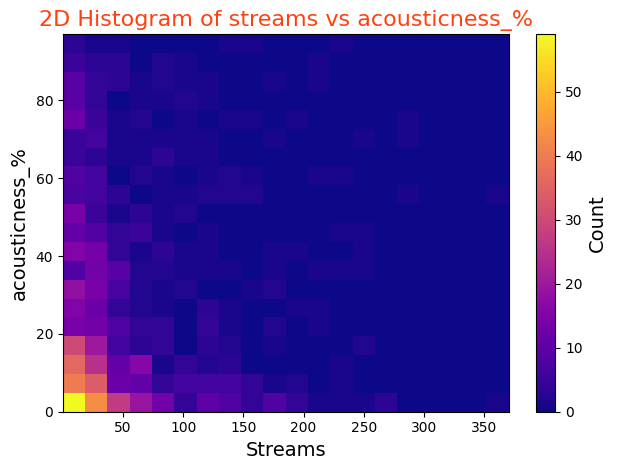

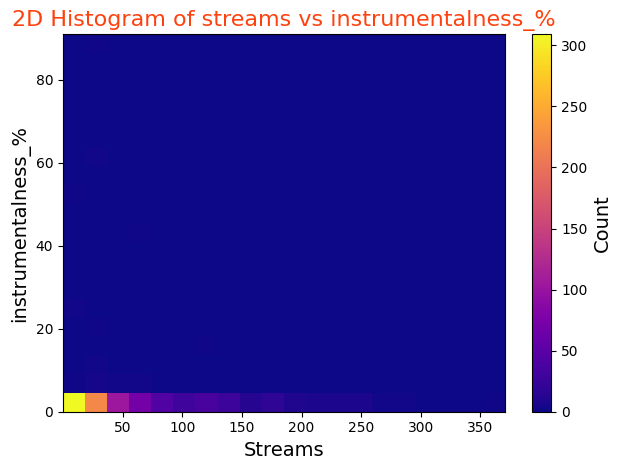

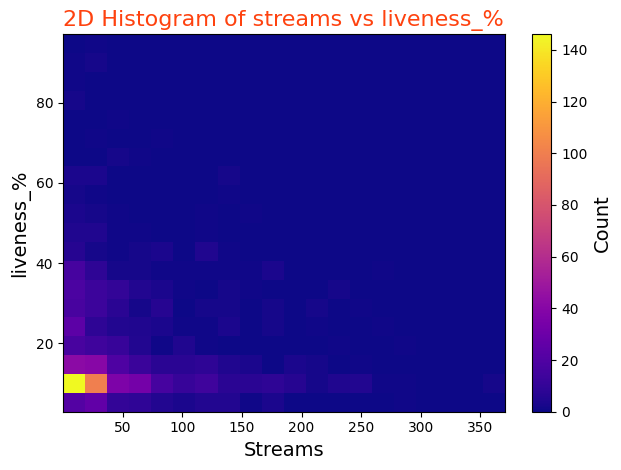

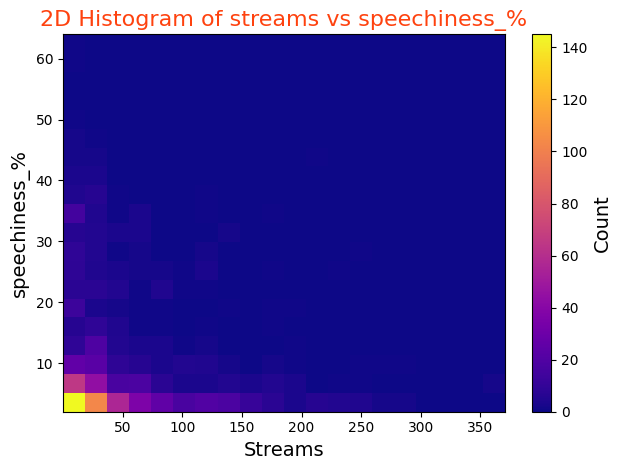

In [ ]:
features = ['bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
for i in features:
    fig, ax = plt.subplots(tight_layout=True)
    hist = ax.hist2d(df['streams_scaled'], df[i], bins=20, cmap='plasma')
    cbar=plt.colorbar(hist[3],ax=ax)
    cbar.set_label('Count', font='Times New Roman', fontsize='14')
    ax.set_xlabel('Streams', font='Times New Roman', fontsize='14')
    ax.set_ylabel(i, font='Times New Roman', fontsize='14')
    ax.set_title(f'2D Histogram of streams vs {i}', color='#FE420F', font='Times New Roman', fontsize='16')
    plt.show()

The series of 2D histograms above explore the relationship between `streams_scaled` and various audio features (BPM, danceability, valence, energy, acousticness, instrumentalness, liveness, and speechiness). These plots help identify which audio features, if any, correlate with higher streaming numbers. For example, songs with lower instrumentalness and acousticness, but higher danceability and energy, tend to have higher streams. However, no strong linear correlation is visible, indicating a complex relationship.

In [ ]:
def colors_from_values(values, palette_name):
    normed = (values - values.min()) / (values.max() - values.min())
    cmap = sns.color_palette(palette_name, as_cmap=True)
    return [cmap(x) for x in normed]

# Convert to list and make sure number of colors matches the number of unique years
unique_years = df['released_year'].unique()


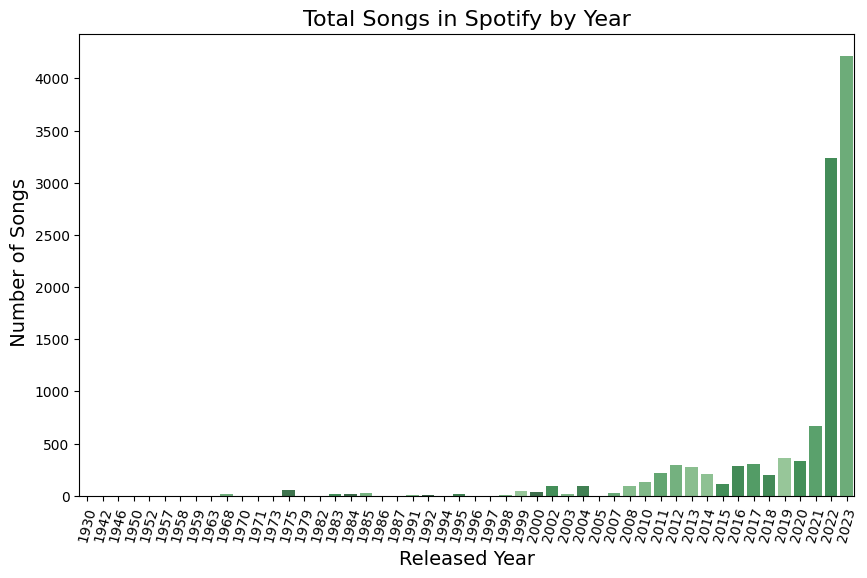

In [ ]:
colors = colors_from_values(df['in_spotify_charts'], "Greens_d")[:len(unique_years)]
df_year = df.groupby('released_year')['in_spotify_charts'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=df_year, x='released_year', y='in_spotify_charts', palette=colors)
plt.xlabel('Released Year', font = 'Script MT Bold', fontsize='14')
plt.ylabel(' Number of Songs', font = 'Script MT Bold', fontsize='14')
plt.title('Total Songs in Spotify by Year',font = 'Script MT Bold',  fontsize='16')
plt.xticks(rotation=75)
plt.show()

This bar plot shows the total number of songs that appeared in Spotify charts, grouped by their release year. It highlights a significant increase in chart-topping songs in recent years, especially in 2022 and 2023, possibly due to more data being available or a higher turnover of popular tracks.

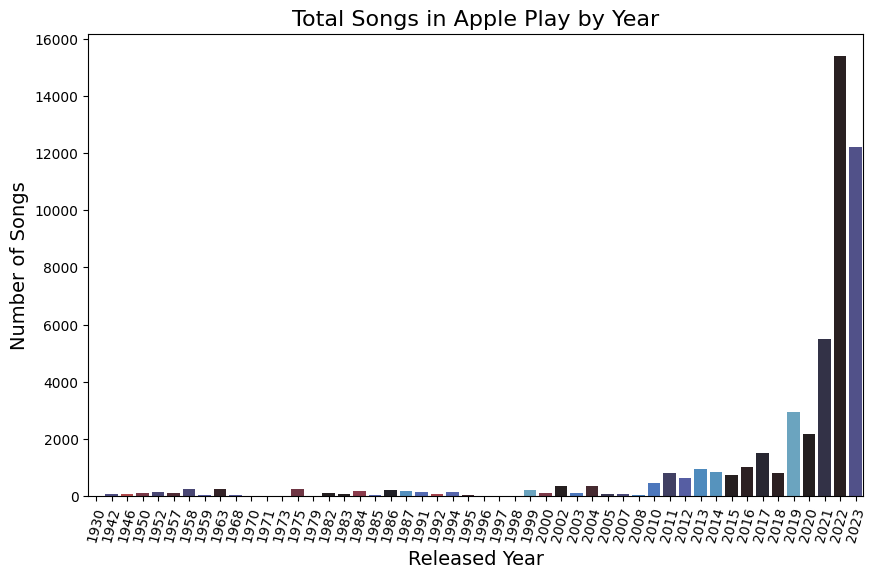

In [ ]:
colors = colors_from_values(df['in_spotify_charts'], "icefire")[:len(unique_years)]
df_year = df.groupby('released_year')['in_apple_charts'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=df_year, x='released_year', y='in_apple_charts', palette=colors)
plt.xlabel('Released Year', font = 'Script MT Bold', fontsize='14')
plt.ylabel('Number of Songs', font = 'Script MT Bold', fontsize='14')
plt.title('Total Songs in Apple Play by Year',font = 'Script MT Bold',  fontsize='16')
plt.xticks(rotation=75)
plt.show()

Similar to Spotify, this bar plot displays the total number of songs in Apple Music charts by release year. It also indicates a rising trend in recent years, with a peak in 2023, suggesting similar patterns of music consumption and chart performance across different platforms.

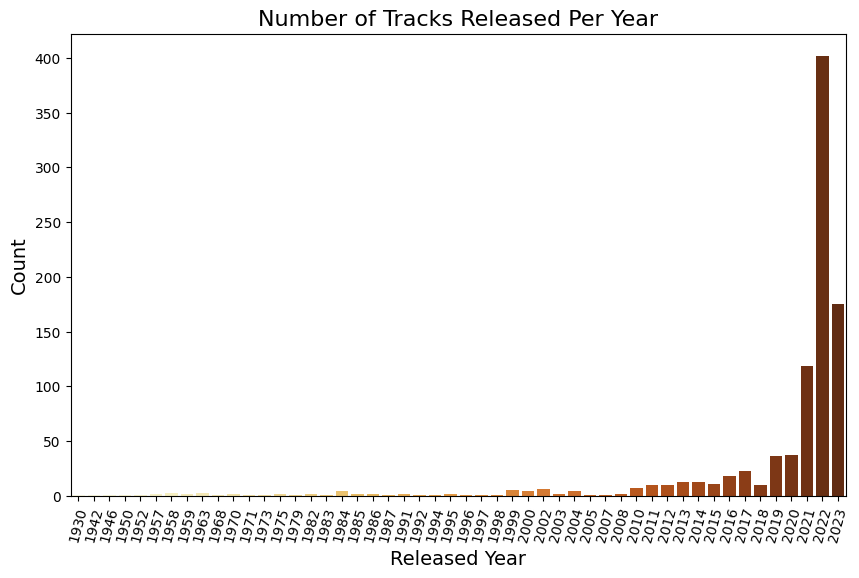

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='released_year', palette='YlOrBr')
plt.xlabel('Released Year', font = 'Bahnschrift', fontsize='14')
plt.ylabel('Count', font = 'Bahnschrift', fontsize='14')
plt.title('Number of Tracks Released Per Year',font = 'Bahnschrift',  fontsize='16')
plt.xticks(rotation=75)
plt.show()

This count plot illustrates the number of tracks released per year in the dataset. It clearly shows a dramatic increase in the number of tracks released in 2022 and 2023, reflecting the dataset's focus on recent popular music or a general trend of increased music production and release.

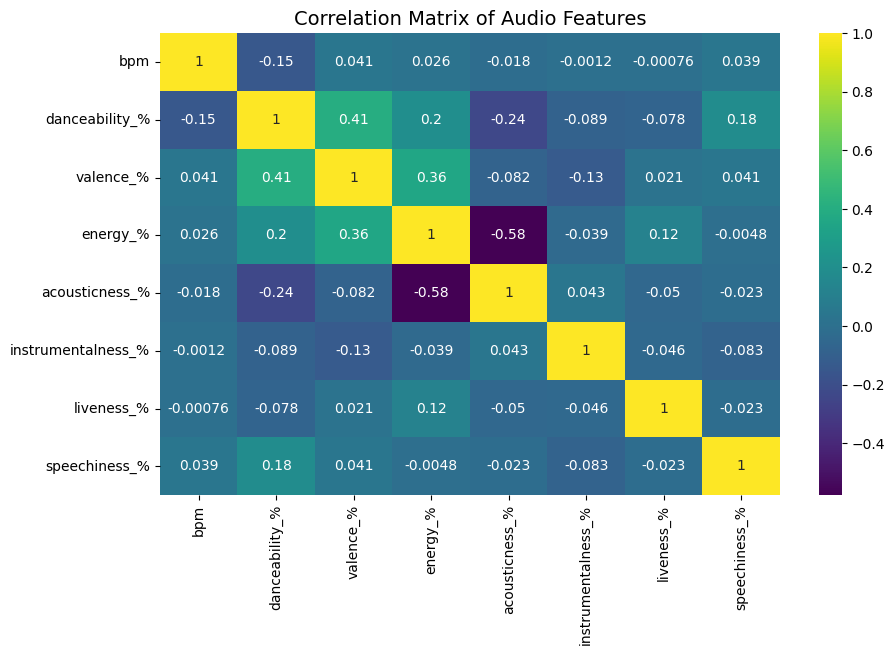

In [ ]:
features = ['bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
plt.figure(figsize=(10, 6))
corr_matrix = df[features].corr()
sns.heatmap(df[features].corr(), annot=True, cmap='viridis')
plt.title('Correlation Matrix of Audio Features',font='Times New Roman', fontsize='14')
plt.show()

The heatmap above visualizes the correlation matrix of various audio features. This helps identify linear relationships between features. For example, energy and acousticness show a negative correlation, while danceability and valence have a positive correlation.

<Figure size 1000x600 with 0 Axes>

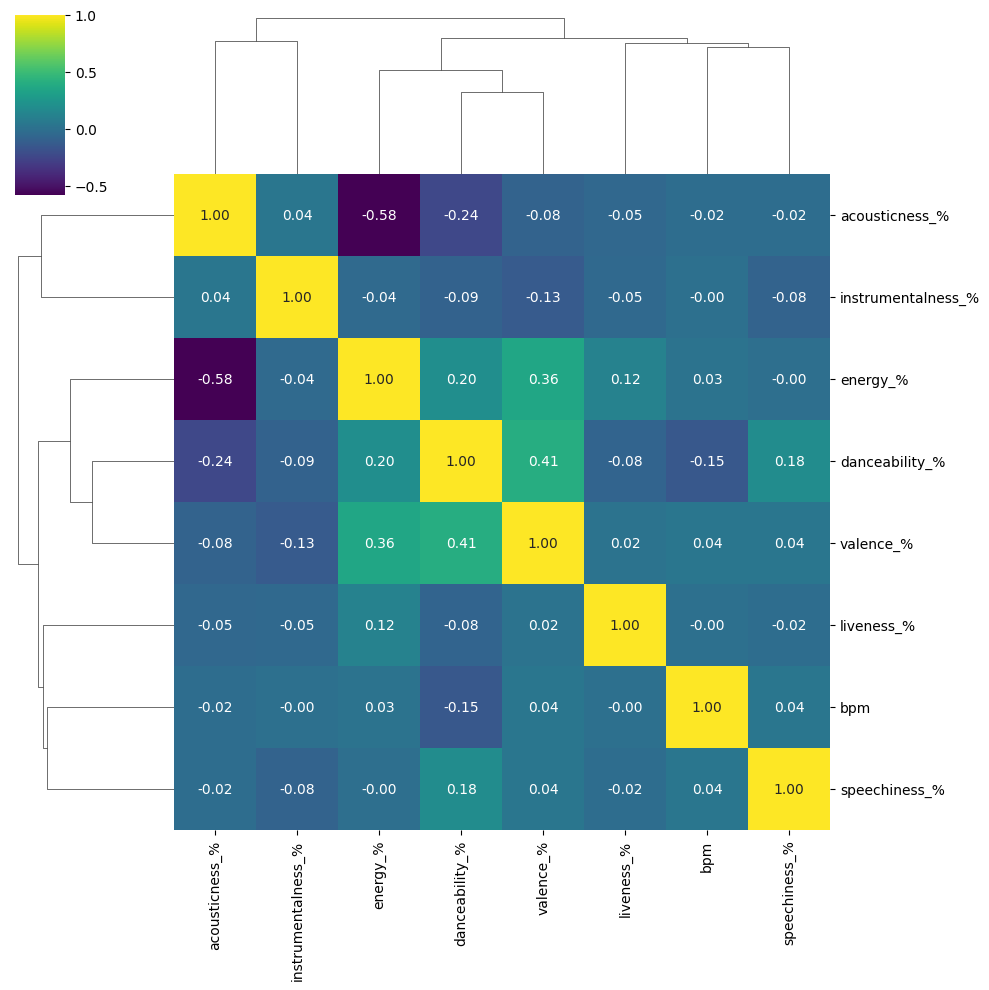

In [ ]:
plt.figure(figsize=(10, 6))
sns.clustermap(corr_matrix, annot=True,cmap='viridis', fmt=".2f")
plt.show()

The clustermap above provides another view of the correlation matrix, with hierarchical clustering applied to group similar features together. This can reveal underlying structures in the relationships between audio features.

In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

This joint plot shows the relationship between `streams_scaled` and `in_spotify_charts`. The scatter plot in the center shows individual data points, while the histograms on the margins show the distribution of each variable. It appears that songs with higher streams also tend to appear more often in Spotify charts, though the relationship isn't strictly linear.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


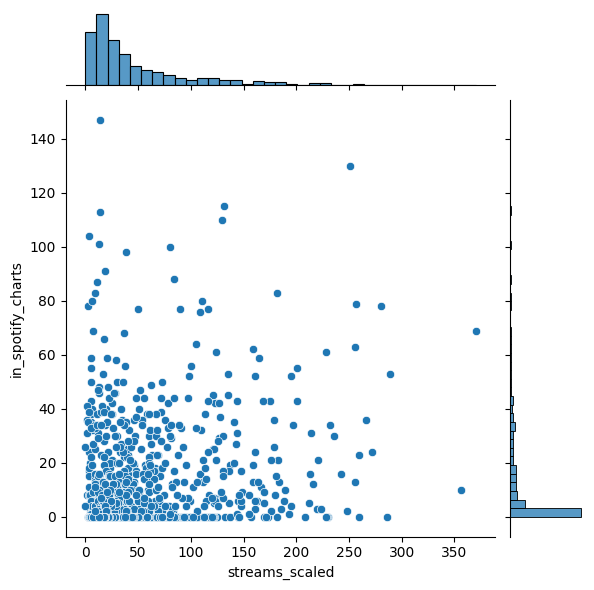

In [ ]:
sns.jointplot(x='streams_scaled', y='in_spotify_charts', data=df, kind='scatter')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


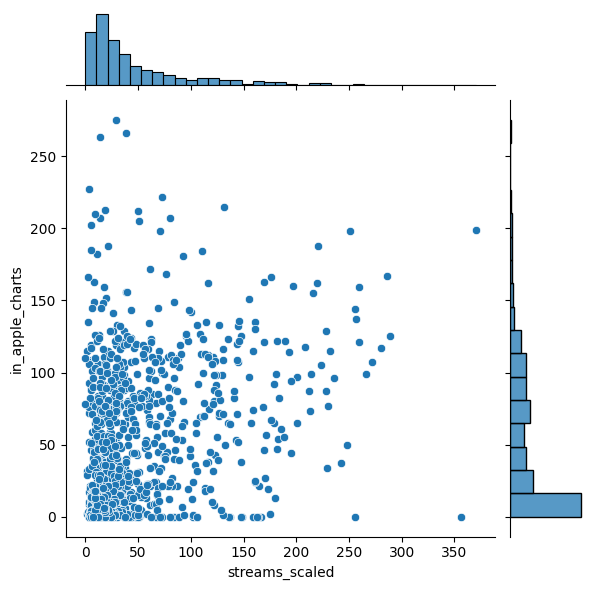

In [ ]:
sns.jointplot(x='streams_scaled',y='in_apple_charts', data=df, kind='scatter')

Similarly, this joint plot illustrates the relationship between `streams_scaled` and `in_apple_charts`. There's a visible trend where songs with more streams are also more frequently in Apple Music charts, indicating that overall popularity often translates across platforms.

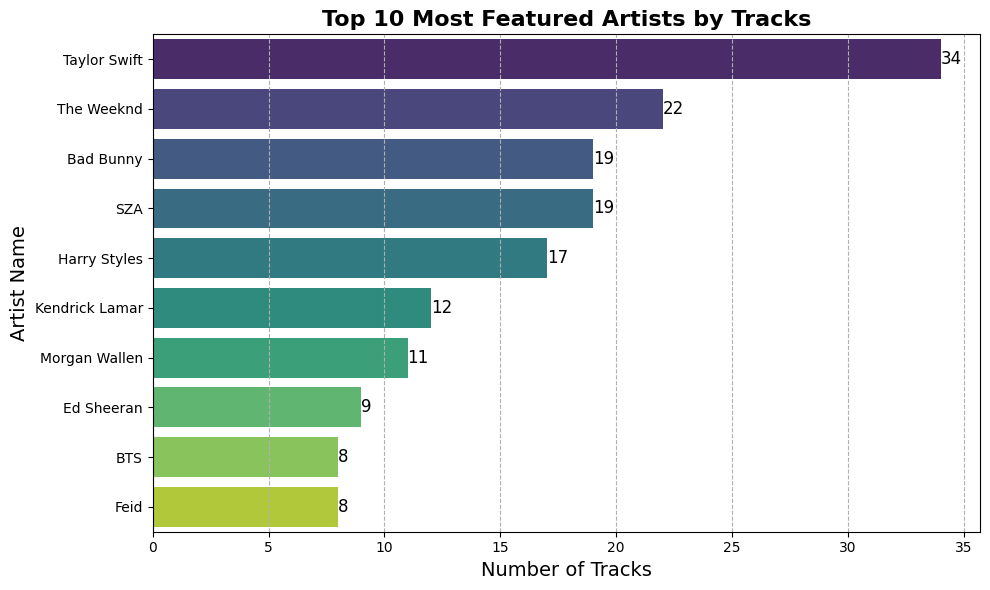

In [ ]:
top_artists = df['artist(s)_name'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')
plt.title('Top 10 Most Featured Artists by Tracks', fontsize=16, fontweight='bold')
plt.xlabel('Number of Tracks', font='Script MT Bold', fontsize=14)
plt.ylabel('Artist Name',font='Script MT Bold', fontsize=14)
for index, value in enumerate(top_artists.values):
    plt.text(value, index, str(value), color='black', ha="left", va="center", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=1)
plt.tight_layout()
plt.show()


This bar plot highlights the top 10 artists based on the number of tracks they have in the dataset. Taylor Swift leads significantly, indicating her dominant presence in the top songs of 2023. This gives an idea of the most prolific artists in the curated list.

In [ ]:
df_streams = df.groupby('streams')['artist(s)_name'].sum().reset_index()

In [ ]:
df_streams

,streams,artist(s)_name
0,2762,"Carin Leon, Grupo Frontera"
1,1365184,"Arijit Singh, Vishal Dadlani, Sukriti Kakar, V..."
2,11599388,"Sog, Ryan Castro, Peso Pluma"
3,11956641,"Mc Pedrinho, DJ 900"
4,14780425,Post Malone
...,...,...
944,2808096550,"Post Malone, Swae Lee"
945,2864791672,Tones and I
946,2887241814,Lewis Capaldi
947,3562543890,Ed Sheeran


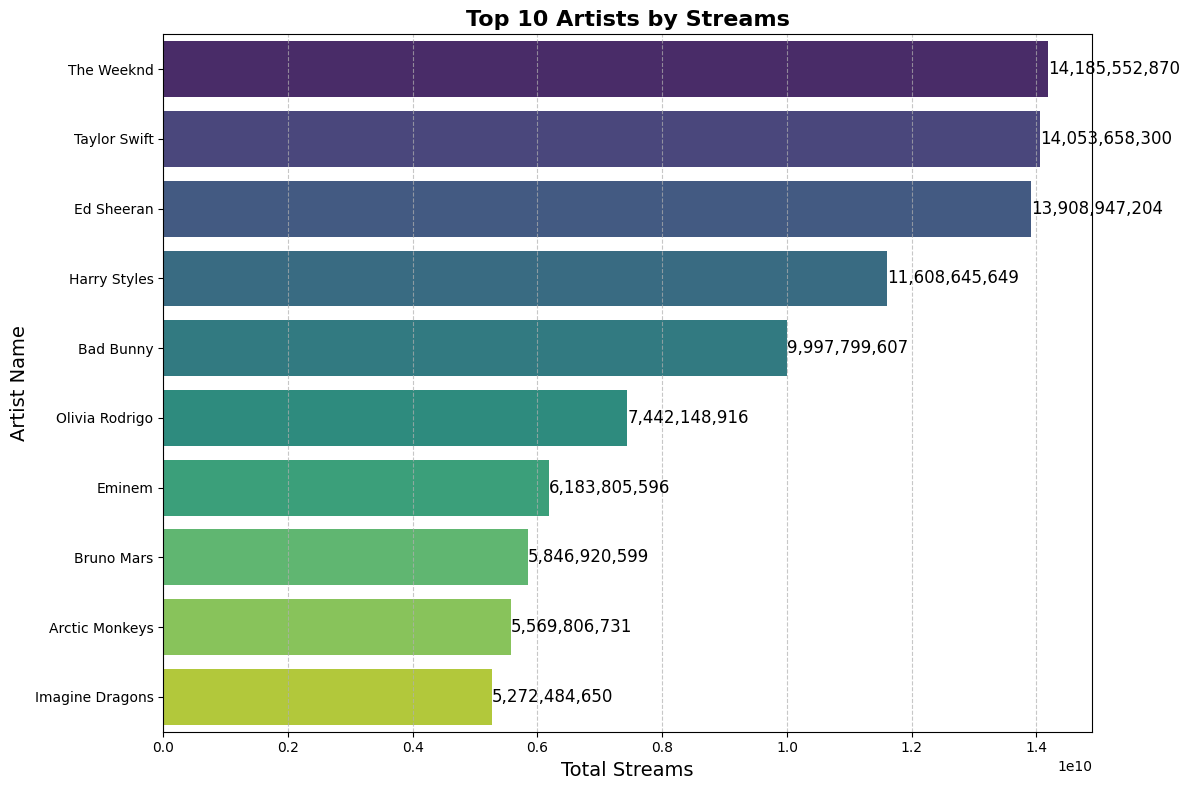

In [ ]:
df_streams = df.groupby('artist(s)_name')['streams'].sum().reset_index().sort_values(by='streams', ascending=False).head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x='streams', y='artist(s)_name', data=df_streams, palette='viridis')
plt.title('Top 10 Artists by Streams', fontsize=16, fontweight='bold')
plt.xlabel('Total Streams', fontsize=14, font='Times New Roman')
plt.ylabel('Artist Name', fontsize=14, font='Times New Roman')
for index, value in enumerate(df_streams['streams']):
    plt.text(value, index, f'{value:,}', color='black', ha="left", va="center", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar plot showcases the top 10 artists by their total streams. The Weeknd and Taylor Swift stand out with exceptionally high stream counts, reinforcing their immense popularity and listenership. This plot directly measures the commercial success of artists based on their accumulated streams.

In [ ]:
df_year = df.groupby('released_year')['artist(s)_name'].sum().reset_index()

In [ ]:
df_year

,released_year,artist(s)_name
0,1930,"Styrx, utku INC, Thezth"
1,1942,"Bing Crosby, John Scott Trotter & His Orchestr..."
2,1946,Nat King Cole
3,1950,"Frank Sinatra, B. Swanson Quartet"
4,1952,Burl Ives
5,1957,Bobby HelmsFrank Sinatra
6,1958,"Brenda LeePerry Como, The Fontane Sisters, Mit..."
7,1959,Dean MartinNat King Cole
8,1963,Andy WilliamsThe RonettesDarlene Love
9,1968,Creedence Clearwater Revival


<Figure size 1600x1600 with 0 Axes>

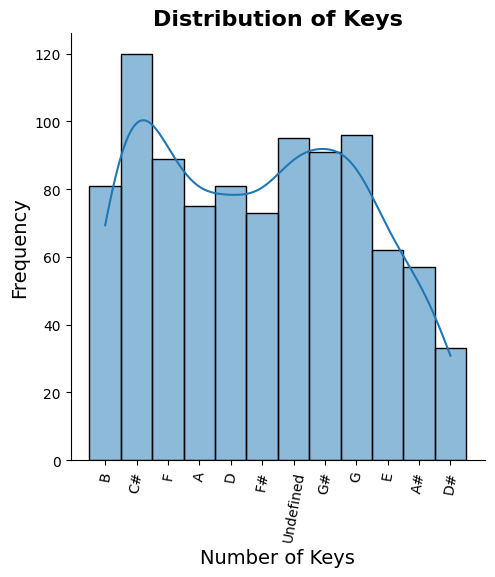

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

plt.figure(figsize=(16, 16))
sns.displot(data=df, x=df['key'], kde=True)
plt.title('Distribution of Keys',fontweight='bold', fontsize=16)
plt.xlabel('Number of Keys',font='Times New Roman', fontsize=14)
plt.ylabel('Frequency',font='Times New Roman', fontsize=14)
plt.xticks(rotation=80)
plt.show()

The distribution plot for 'key' shows the frequency of different musical keys in the dataset. 'C#' appears to be the most common key, followed by 'Undefined' (which we filled in for missing values), 'G#', and 'F'. This could suggest common keys used in popular music.

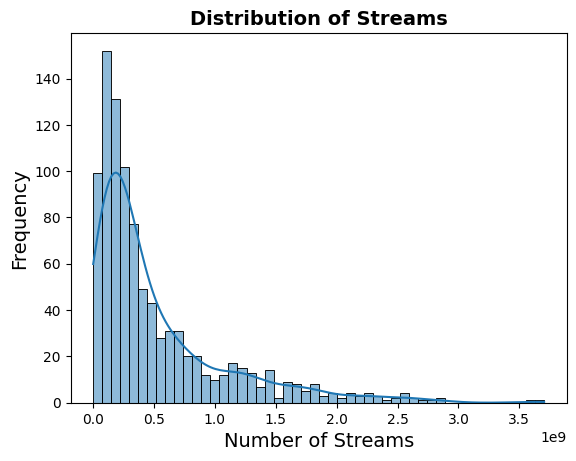

In [ ]:
sns.histplot(df['streams'], bins=50, kde=True)
plt.title('Distribution of Streams', fontweight='bold', fontsize=14)
plt.xlabel('Number of Streams', font='Times New Roman', fontsize=14)
plt.ylabel('Frequency', font='Times New Roman',fontsize=14)
plt.show()

The histogram above shows the distribution of song streams. It's heavily skewed to the right, indicating that a large number of songs have relatively low streams, while a smaller number of songs achieve extremely high stream counts. This is typical for popularity metrics in music.

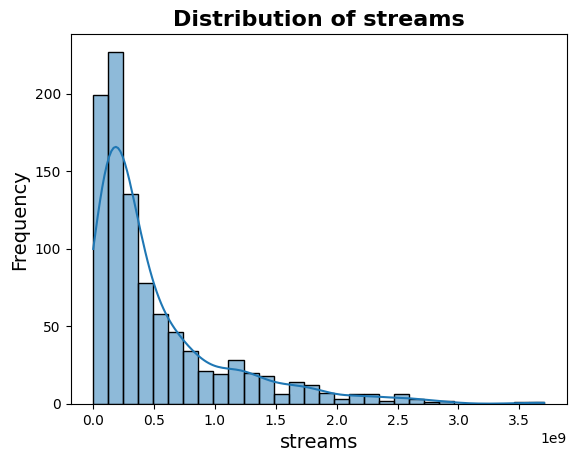

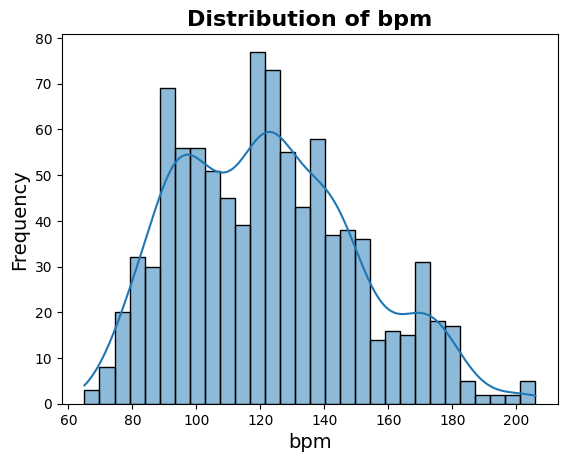

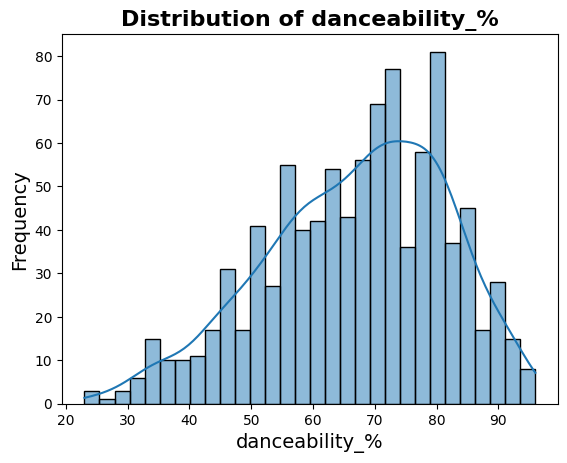

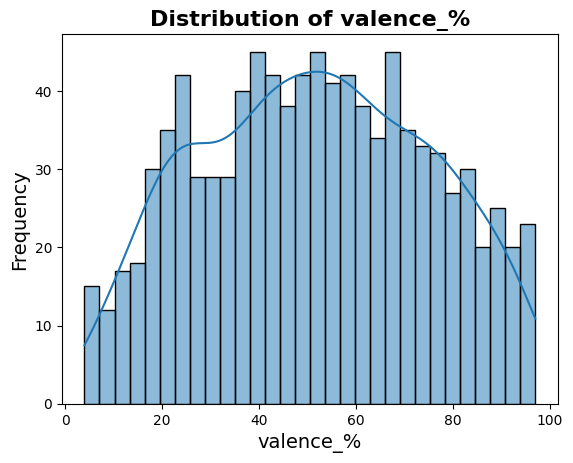

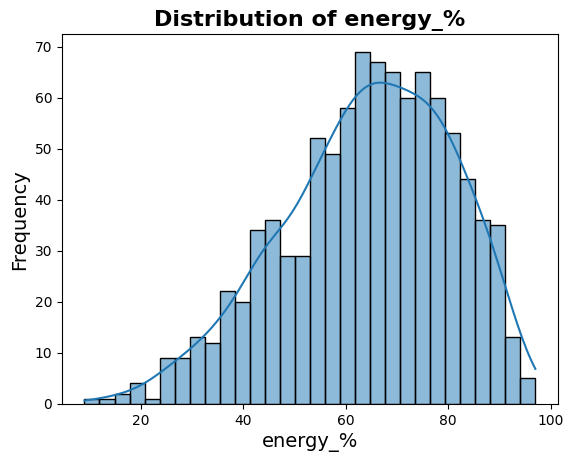

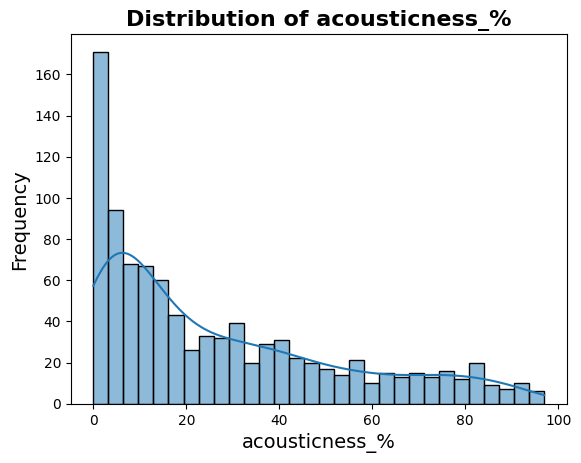

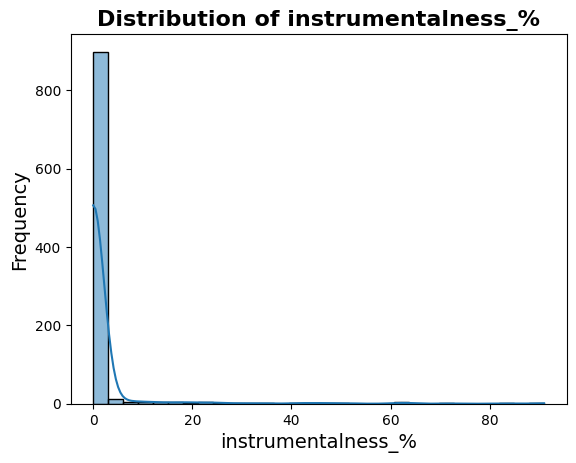

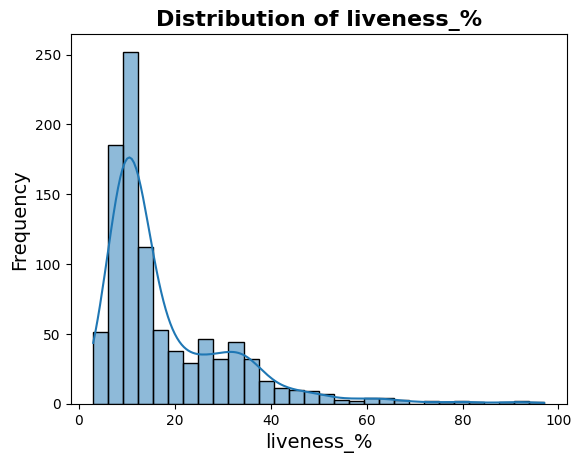

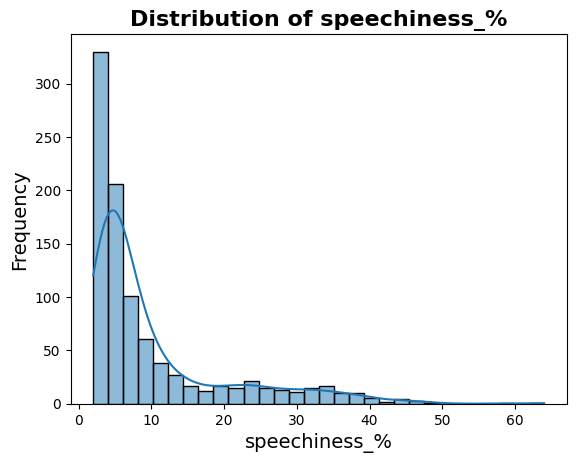

In [ ]:
features = ['streams', 'bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
for feature in features:
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}', fontweight='bold', fontsize=16)
    plt.xlabel(feature, fontsize=14, )
    plt.ylabel('Frequency', fontsize=14)
    plt.show()

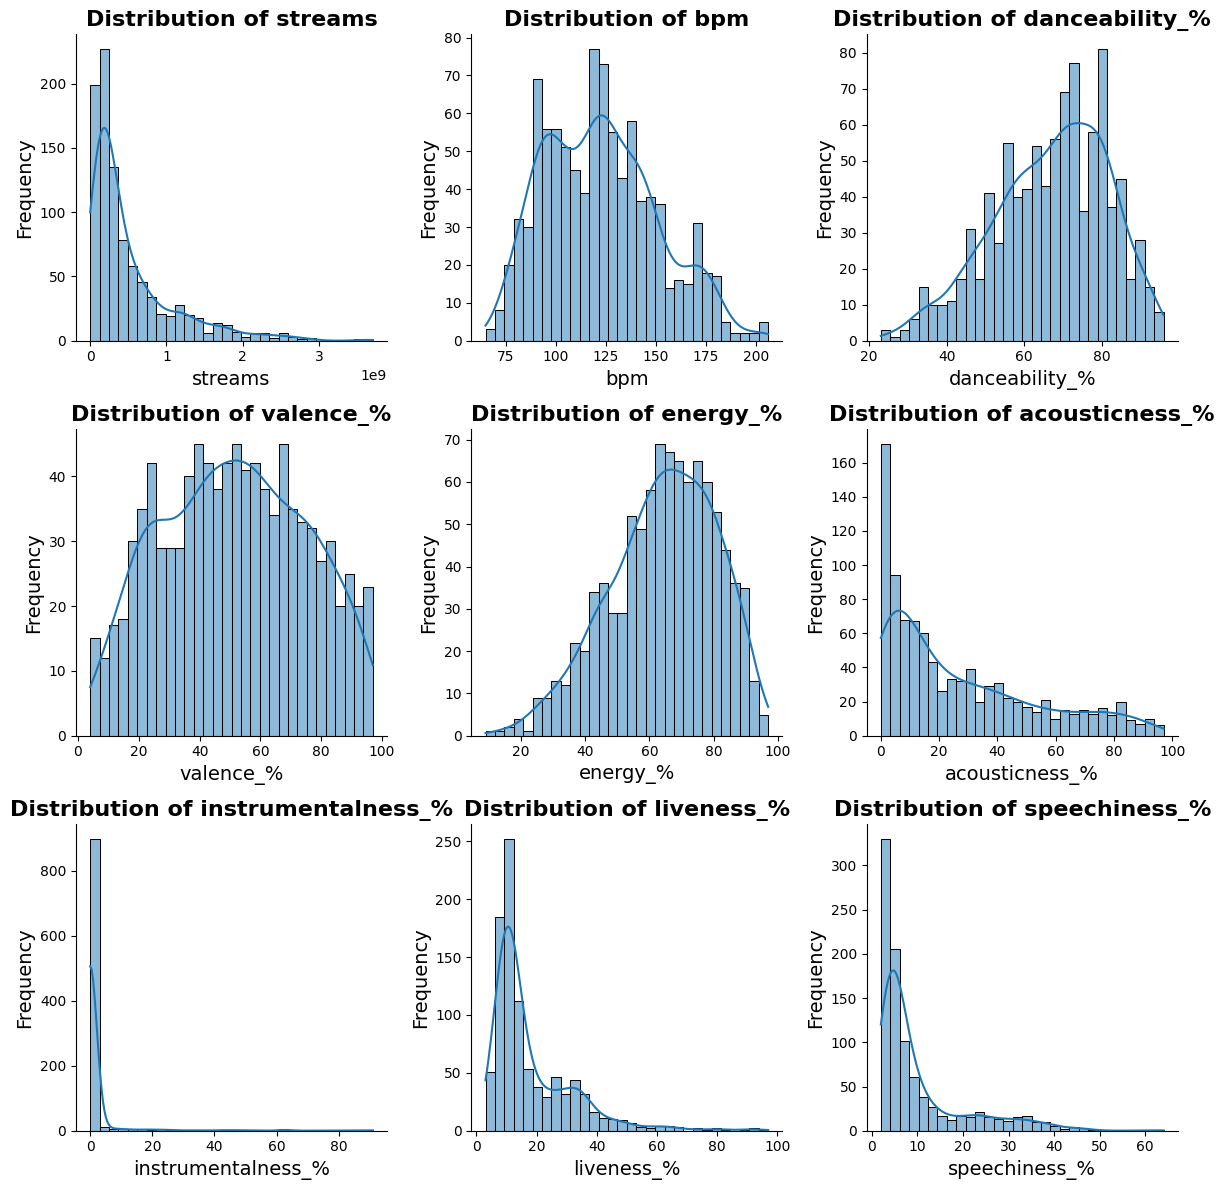

In [ ]:
features = ['streams', 'bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
g = sns.FacetGrid(pd.melt(df, value_vars=features), col='variable', col_wrap=3, sharex=False, sharey=False, height=4)
g.map(sns.histplot, 'value', kde=True, bins=30)
for ax, feature in zip(g.axes.flat, features):
    ax.set_title(f'Distribution of {feature}', fontweight='bold', fontsize=16)
    ax.set_xlabel(feature, fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.show()

This set of histograms visualizes the distribution of various audio features: streams, BPM, danceability, valence, energy, acousticness, instrumentalness, liveness, and speechiness. Each plot provides insights into the typical range and spread of these features among the top songs. For example, streams, acousticness, instrumentalness, liveness, and speechiness are right-skewed, while danceability, valence, and energy tend to be more centrally distributed.

### Conclusion

This Exploratory Data Analysis has provided valuable insights into the top Spotify songs of 2023. We observed several key trends and relationships:

*   **Data Quality:** Initial inspection revealed the need for data cleaning, specifically in handling non-numeric 'streams' values and missing 'key' and 'in_shazam_charts' entries. After cleaning, the dataset is robust with no missing values or duplicates.
*   **Release Date Trends:** There's a clear and significant increase in the number of songs released and charting in Spotify and Apple Music in 2022 and 2023, indicating a rapid evolution in popular music and potentially a bias towards recent data in the dataset.
*   **Audio Feature Distributions:** Most audio features exhibit distinct distributions. Streams, acousticness, instrumentalness, liveness, and speechiness are right-skewed, suggesting that a small number of songs have very high values for these features, while the majority have lower values. Danceability, valence, and energy tend to be more centrally distributed.
*   **Feature Relationships:**
    *   Energy and danceability show a positive correlation, with a concentration of songs being both energetic and danceable.
    *   Liveness and acousticness often show an inverse relationship, with popular songs tending to have lower values for both, pointing towards studio-produced tracks.
    *   While some patterns emerged, a strong linear correlation between individual audio features and `streams_scaled` was not consistently observed, implying that popularity is likely influenced by a complex interplay of multiple factors rather than single features.
*   **Artist Popularity:** The analysis highlighted dominant artists like Taylor Swift and The Weeknd, who appear frequently and have exceptionally high stream counts, respectively.
*   **Key Distribution:** 'C#' emerged as a frequently used musical key among the top songs, alongside 'G#' and 'F'.

Overall, the EDA has provided a foundational understanding of the dataset's characteristics, preparing it for further analysis, such as modeling or more in-depth feature engineering.